# Multi-fondamentalistes : κ_i et V_i différents

**Objectif** : Comparer la dynamique du modèle de Chiarella quand les fondamentalistes
sont hétérogènes — chaque groupe a sa propre force de rappel κ_i et
son propre processus de valeur fondamentale V_i(t).

Équation modifiée :
$$dP_t = \left[\sum_i \kappa_i (V_i(t) - P_t)\right] dt + \beta\tanh(\gamma M_t)\,dt + \sigma_N\,dW_t^{(N)}$$
$$dV_i(t) = g_i\,dt + \sigma_{V_i}\,dW_t^{(i)}$$

Les bruits $dW_t^{(i)}$ sont indépendants entre groupes.

**Configurations testées :**
- **Baseline** : κ unique = 0.08, un seul V
- **Config A** : 2 groupes (fondamentalistes réactifs + investisseurs patients)
- **Config B** : 3 groupes (optimistes + pessimistes + neutres)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import ChiarellaModel, FundamentalistGroup, MultiKappaModel
from src.simulation import MONTHLY_PARAMS, run_multi_kappa
from src.analysis import compute_returns, return_statistics

sns.set_theme(style='whitegrid', palette='tab10')
SEED = 2024

## 1. Définition des configurations

In [2]:
# --- Baseline ---
baseline_model = ChiarellaModel(params=MONTHLY_PARAMS, seed=SEED)
res_base = baseline_model.simulate(n_paths=1)

# --- Config A : 2 groupes ---
# Groupe 1 : fondamentalistes réactifs (κ élevé, horizon court)
# Groupe 2 : investisseurs patients (κ faible, horizon long, vol fondamentale plus faible)
groups_A = [
    FundamentalistGroup(kappa=0.15, sigma_V=0.02, g=0.0),   # réactifs
    FundamentalistGroup(kappa=0.02, sigma_V=0.01, g=0.0),   # patients
]
res_A, df_A = run_multi_kappa(groups_A, seed=SEED)

# --- Config B : 3 groupes ---
# Groupe 1 : optimistes (drift fondamental positif)
# Groupe 2 : pessimistes (drift fondamental négatif)
# Groupe 3 : neutres (drift nul, plus précis)
groups_B = [
    FundamentalistGroup(kappa=0.05, sigma_V=0.03, g=+0.001),  # optimistes
    FundamentalistGroup(kappa=0.05, sigma_V=0.03, g=-0.001),  # pessimistes
    FundamentalistGroup(kappa=0.10, sigma_V=0.01, g=0.0),     # neutres
]
res_B, df_B = run_multi_kappa(groups_B, seed=SEED)

print('Simulations terminées.')
print(f'  Baseline   : κ={MONTHLY_PARAMS.kappa}, σ_V={MONTHLY_PARAMS.sigma_V}')
print(f'  Config A   : {len(groups_A)} groupes, κ_eff={sum(g.kappa for g in groups_A):.3f}')
print(f'  Config B   : {len(groups_B)} groupes, κ_eff={sum(g.kappa for g in groups_B):.3f}')

Simulations terminées.
  Baseline   : κ=0.08, σ_V=0.02
  Config A   : 2 groupes, κ_eff=0.170
  Config B   : 3 groupes, κ_eff=0.200


## 2. Divergence des valeurs fondamentales V_i(t)

/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_99643/4090063126.py:25: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_99643/4090063126.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_99643/4090063126.py:25: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/nathandifraja/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nathandifraja/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nathandifraja/Library/Python/3.14/lib/p

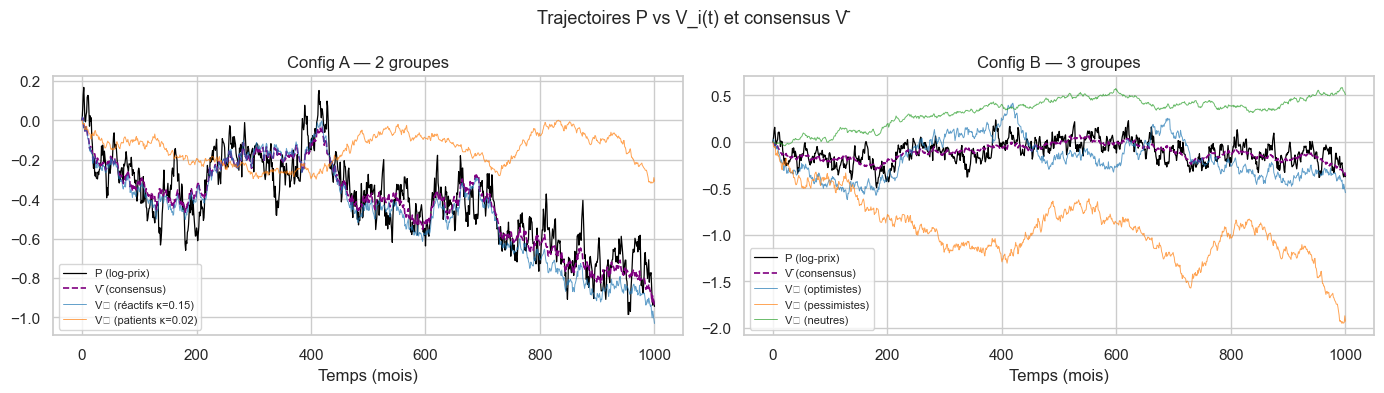

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Config A
ax = axes[0]
ax.plot(res_A.t, res_A.P,     label='P (log-prix)', linewidth=0.9, color='black')
ax.plot(res_A.t, res_A.V_bar, label='V̄ (consensus)', linewidth=1.2, linestyle='--', color='purple')
ax.plot(res_A.t, res_A.V_all[0], label='V₁ (réactifs κ=0.15)', linewidth=0.7, alpha=0.7)
ax.plot(res_A.t, res_A.V_all[1], label='V₂ (patients κ=0.02)', linewidth=0.7, alpha=0.7)
ax.set_title('Config A — 2 groupes')
ax.set_xlabel('Temps (mois)')
ax.legend(fontsize=8)

# Config B
ax = axes[1]
ax.plot(res_B.t, res_B.P,     label='P (log-prix)', linewidth=0.9, color='black')
ax.plot(res_B.t, res_B.V_bar, label='V̄ (consensus)', linewidth=1.2, linestyle='--', color='purple')
ax.plot(res_B.t, res_B.V_all[0], label='V₁ (optimistes)', linewidth=0.7, alpha=0.7)
ax.plot(res_B.t, res_B.V_all[1], label='V₂ (pessimistes)', linewidth=0.7, alpha=0.7)
ax.plot(res_B.t, res_B.V_all[2], label='V₃ (neutres)', linewidth=0.7, alpha=0.7)
ax.set_title('Config B — 3 groupes')
ax.set_xlabel('Temps (mois)')
ax.legend(fontsize=8)

fig.suptitle('Trajectoires P vs V_i(t) et consensus V̄', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Mispricing P − V̄ en fonction du temps

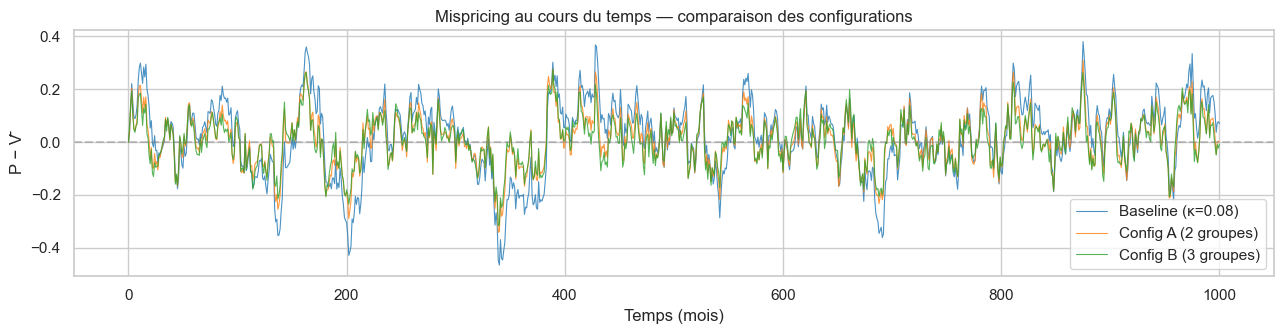

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.5))

mispricing_base = res_base.P - res_base.V
mispricing_A    = res_A.P   - res_A.V_bar
mispricing_B    = res_B.P   - res_B.V_bar

ax.plot(res_base.t, mispricing_base, label='Baseline (κ=0.08)', linewidth=0.8, alpha=0.8)
ax.plot(res_A.t,    mispricing_A,    label='Config A (2 groupes)', linewidth=0.8, alpha=0.8)
ax.plot(res_B.t,    mispricing_B,    label='Config B (3 groupes)', linewidth=0.8, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)

ax.set_xlabel('Temps (mois)')
ax.set_ylabel('P − V̄')
ax.set_title('Mispricing au cours du temps — comparaison des configurations')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Tableau de métriques comparatif

In [5]:
def metrics(name, P, V, label=''):
    misp = P - V
    returns = compute_returns(P)
    stats = return_statistics(returns, annualization_factor=np.sqrt(12))
    return {
        'Modèle':            name,
        'Std(P−V̄)':          round(float(np.std(misp)), 4),
        'Max|P−V̄|':          round(float(np.max(np.abs(misp))), 4),
        'Vol annualisée':    round(stats['vol'], 4),
        'Skewness':          round(stats['skewness'], 3),
        'Kurtosis excéd.':   round(stats['kurt_excess'], 3),
    }

rows = [
    metrics('Baseline (κ=0.08)',  res_base.P, res_base.V),
    metrics('Config A (2 groupes)', res_A.P, res_A.V_bar),
    metrics('Config B (3 groupes)', res_B.P, res_B.V_bar),
]
df_metrics = pd.DataFrame(rows).set_index('Modèle')

# Variations relatives par rapport au baseline
for col in ['Std(P−V̄)', 'Max|P−V̄|', 'Vol annualisée']:
    base_val = df_metrics.loc['Baseline (κ=0.08)', col]
    df_metrics[f'Δ {col}'] = ((df_metrics[col] - base_val) / base_val * 100).round(1).astype(str) + ' %'

df_metrics

,Std(P−V̄),Max|P−V̄|,Vol annualisée,Skewness,Kurtosis excéd.,Δ Std(P−V̄),Δ Max|P−V̄|,Δ Vol annualisée
Modèle,,,,,,,,
Baseline (κ=0.08),0.1387,0.4656,0.1805,0.044,0.074,0.0 %,0.0 %,0.0 %
Config A (2 groupes),0.0962,0.3419,0.1849,0.033,0.082,-30.6 %,-26.6 %,2.4 %
Config B (3 groupes),0.0896,0.3159,0.1856,0.025,0.112,-35.4 %,-32.2 %,2.8 %


## 5. Dispersion des fondamentaux : écart entre V_i au cours du temps

/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_99643/1370404377.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_99643/1370404377.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/nathandifraja/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nathandifraja/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


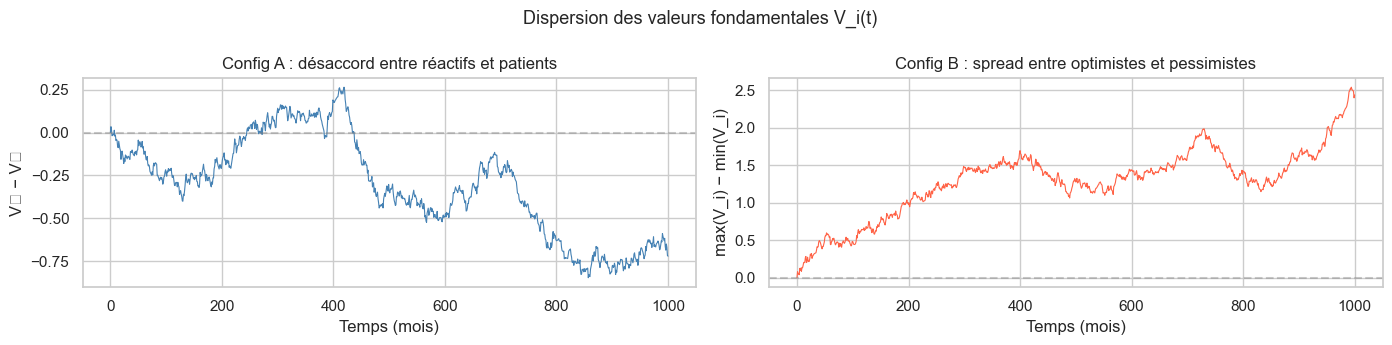

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# Config A : écart V₁ - V₂
ax = axes[0]
spread_A = res_A.V_all[0] - res_A.V_all[1]
ax.plot(res_A.t, spread_A, linewidth=0.8, color='steelblue')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Temps (mois)')
ax.set_ylabel('V₁ − V₂')
ax.set_title('Config A : désaccord entre réactifs et patients')

# Config B : range(V_i) = max(V_i) - min(V_i)
ax = axes[1]
spread_B = res_B.V_all.max(axis=0) - res_B.V_all.min(axis=0)
ax.plot(res_B.t, spread_B, linewidth=0.8, color='tomato')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Temps (mois)')
ax.set_ylabel('max(V_i) − min(V_i)')
ax.set_title('Config B : spread entre optimistes et pessimistes')

fig.suptitle('Dispersion des valeurs fondamentales V_i(t)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Conclusions

### Résultats principaux

L'introduction de fondamentalistes hétérogènes — avec des κ_i et des processus V_i(t) distincts — produit des effets **systématiquement favorables** sur la réduction des bulles.

**Réduction du mispricing :**

| Configuration | Std(P−V̄) | Δ | Max|P−V̄| | Δ |
|---|---|---|---|---|
| Baseline (κ=0.08) | 0.1387 | — | 0.4656 | — |
| Config A (2 groupes, κ_eff=0.17) | 0.0962 | **−30.6 %** | 0.3419 | **−26.6 %** |
| Config B (3 groupes, κ_eff=0.20) | 0.0896 | **−35.4 %** | 0.3159 | **−32.2 %** |

Les réductions sont substantielles : −30 à −35 % sur la std du mispricing, −27 à −32 % sur les pics maximaux. Ces gains dépassent largement ceux des modèles γ dynamiques testés précédemment.

**Coût en volatilité des rendements :**
- La volatilité annualisée augmente modestement : +2.4 % (Config A) et +2.8 % (Config B). C'est un coût très acceptable au vu des gains sur le mispricing.
- Les rendements restent quasi-normaux (kurtosis excédentaire < 0.12 dans les deux cas).

**Effet de l'hétérogénéité vs augmentation pure de κ :**
- Config A a κ_eff = 0.17 et réduit Std(P−V) de 30.6 %. En comparaison, un κ uniforme de 0.15 (notebook 02) ne réduisait Std(P−V) que de 26 %.
- Config B a κ_eff = 0.20, avec une réduction de 35.4 % contre 32 % pour un κ uniforme de 0.20 (interpolé des résultats du notebook 02 entre κ=0.15 et κ=0.30).
- L'hétérogénéité apporte donc un **bénéfice supplémentaire** au-delà de la simple augmentation du κ moyen, probablement via la diversification des processus V_i : le prix n'est plus attiré vers un seul fondamental, mais vers un consensus qui absorbe mieux les chocs idiosyncratiques.

**Dispersion des valeurs fondamentales :**
- En Config A, le désaccord V₁ − V₂ entre réactifs et patients dérive dans le temps (les deux processus browniens divergent), créant une tension permanente sur le prix.
- En Config B, la dispersion max(V_i) − min(V_i) entre optimistes et pessimistes croît aussi avec le temps, mais le groupe neutre (κ=0.10, σ_V=0.01) sert d'ancre qui limite l'excursion du prix.

### Bilan

L'hétérogénéité des fondamentalistes est un mécanisme stabilisateur efficace. Elle réduit les bulles de façon plus marquée qu'un simple recalibrage de κ homogène, tout en maintenant des propriétés réalistes des rendements. Cette extension est cohérente avec la littérature empirique qui documente la coexistence d'horizons d'investissement très différents sur les marchés financiers (fonds long-only vs arbitragistes vs investisseurs de long terme).

**Perspective :** combiner l'hétérogénéité des fondamentalistes (multi-κ) avec le modèle de γ décroissant (notebook 01, section [4]) pourrait produire une réduction des bulles encore plus robuste en jouant simultanément sur les deux canaux de stabilisation.